In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
import os

print(os.listdir())

['.config', 'cleaned_adult.csv', 'sample_data']


In [9]:
import pandas as pd

df = pd.read_csv("cleaned_adult.csv")

df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [10]:
print(df.shape)
print(df.columns.tolist())

(32537, 15)
['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income']


In [11]:
# Regression Target
y_reg = df["hours.per.week"]

# Classification Target
df["income"] = df["income"].map({"<=50K": 0, ">50K": 1})

y_clf = df["income"]

# Features
X = df.drop(["hours.per.week", "income"], axis=1)

print(X.shape)
print(y_reg.shape)
print(y_clf.shape)

(32537, 13)
(32537,)
(32537,)


In [12]:
X = pd.get_dummies(X, drop_first=True)

print(X.shape)
X.head()

(32537, 99)


,age,fnlwgt,education.num,capital.gain,capital.loss,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,90,77053,9,0,4356,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,82,132870,9,0,4356,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
2,66,186061,10,0,4356,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,54,140359,4,0,3900,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
4,41,264663,10,0,3900,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False


In [13]:
from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [15]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_reg_scaled = scaler.fit_transform(X_train_reg)
X_test_reg_scaled = scaler.transform(X_test_reg)

X_train_clf_scaled = scaler.fit_transform(X_train_clf)
X_test_clf_scaled = scaler.transform(X_test_clf)

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()

lr.fit(X_train_reg_scaled, y_train_reg)

y_pred_reg = lr.predict(X_test_reg_scaled)

print("MSE:", mean_squared_error(y_test_reg, y_pred_reg))
print("R2 Score:", r2_score(y_test_reg, y_pred_reg))

MSE: 119.32979108234368
R2 Score: 0.19978804153882912


In [18]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

coef_df["Absolute"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values("Absolute", ascending=False)

print(coef_df.head(10))

                         Feature  Coefficient  Absolute
8              workclass_Private     1.804652  1.804652
50        relationship_Own-child    -1.757771  1.757771
9         workclass_Self-emp-inc     1.663529  1.663529
37    occupation_Exec-managerial     1.548184  1.548184
31  marital.status_Never-married    -1.448801  1.448801
10    workclass_Self-emp-not-inc     1.427447  1.427447
0                            age    -1.396481  1.396481
38    occupation_Farming-fishing     1.349906  1.349906
57                      sex_Male     1.270104  1.270104
47   occupation_Transport-moving     1.219891  1.219891


In [19]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_reg_scaled, y_train_reg)

ridge_pred = ridge.predict(X_test_reg_scaled)

print("Ridge R2:", r2_score(y_test_reg, ridge_pred))

Ridge R2: 0.19978833799593143


In [20]:
print(y_train_clf.value_counts())
print(y_train_clf.value_counts(normalize=True))

income
0    19758
1     6271
Name: count, dtype: int64
income
0    0.759076
1    0.240924
Name: proportion, dtype: float64


In [21]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

log_model.fit(X_train_clf_scaled, y_train_clf)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [22]:
y_pred = log_model.predict(X_test_clf_scaled)
y_prob = log_model.predict_proba(X_test_clf_scaled)[:, 1]

In [23]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Confusion Matrix")
print(confusion_matrix(y_test_clf, y_pred))

print("\nClassification Report")
print(classification_report(y_test_clf, y_pred))

print("Accuracy :", accuracy_score(y_test_clf, y_pred))
print("Precision:", precision_score(y_test_clf, y_pred))
print("Recall   :", recall_score(y_test_clf, y_pred))
print("F1 Score :", f1_score(y_test_clf, y_pred))

Confusion Matrix
[[3917 1023]
 [ 278 1290]]

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.79      0.86      4940
           1       0.56      0.82      0.66      1568

    accuracy                           0.80      6508
   macro avg       0.75      0.81      0.76      6508
weighted avg       0.84      0.80      0.81      6508

Accuracy : 0.8000921942224954
Precision: 0.5577172503242542
Recall   : 0.8227040816326531
F1 Score : 0.6647771192991497


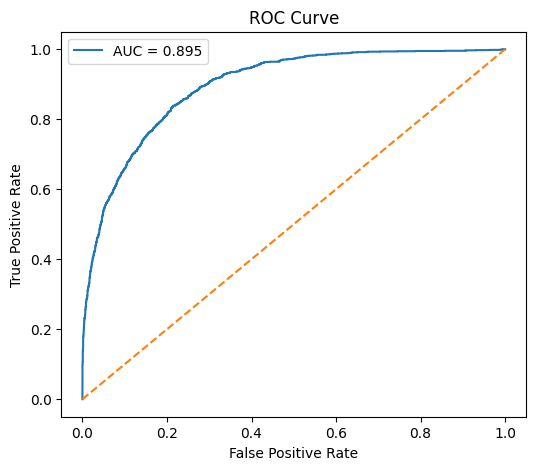

AUC Score: 0.8954325632074693


In [24]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test_clf, y_prob)

auc = roc_auc_score(y_test_clf, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", auc)

In [25]:
thresholds = [0.30,0.40,0.50,0.60,0.70]

results=[]

for t in thresholds:

    pred=(y_prob>=t).astype(int)

    p=precision_score(y_test_clf,pred)
    r=recall_score(y_test_clf,pred)
    f=f1_score(y_test_clf,pred)

    results.append([t,p,r,f])

threshold_df=pd.DataFrame(results,
columns=["Threshold","Precision","Recall","F1"])

print(threshold_df)

   Threshold  Precision    Recall        F1
0        0.3   0.466838  0.929209  0.621454
1        0.4   0.508837  0.881378  0.645191
2        0.5   0.557717  0.822704  0.664777
3        0.6   0.617167  0.747449  0.676089
4        0.7   0.679894  0.655612  0.667532


In [26]:
log_model2 = LogisticRegression(
    C=0.01,
    max_iter=1000,
    class_weight="balanced"
)

log_model2.fit(X_train_clf_scaled,y_train_clf)

prob2=log_model2.predict_proba(X_test_clf_scaled)[:,1]

pred2=log_model2.predict(X_test_clf_scaled)

print("Precision:",precision_score(y_test_clf,pred2))
print("Recall:",recall_score(y_test_clf,pred2))
print("AUC:",roc_auc_score(y_test_clf,prob2))

Precision: 0.5555081127241673
Recall: 0.829719387755102
AUC: 0.8951623564405519


In [29]:
diff=[]

for i in range(500):

    idx=np.random.choice(
        len(y_test_clf),
        size=len(y_test_clf),
        replace=True
    )

    auc1=roc_auc_score(
        y_test_clf.iloc[idx],
        y_prob[idx]
    )

    auc2=roc_auc_score(
        y_test_clf.iloc[idx],
        prob2[idx]
    )

    diff.append(auc1-auc2)

print("Mean Difference:",np.mean(diff))

print("95% CI:",
      np.percentile(diff,2.5),
      np.percentile(diff,97.5))

Mean Difference: 0.0003469643391311601
95% CI: -0.0010642627923923287 0.0015733539714577137


In [30]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "R2 Score": [
        r2_score(y_test_reg, y_pred_reg),
        r2_score(y_test_reg, ridge_pred)
    ],
    "MSE": [
        mean_squared_error(y_test_reg, y_pred_reg),
        mean_squared_error(y_test_reg, ridge_pred)
    ]
})

print(comparison)

comparison.to_csv("ridge_vs_linear.csv", index=False)

               Model  R2 Score         MSE
0  Linear Regression  0.199788  119.329791
1   Ridge Regression  0.199788  119.329747


In [31]:
logistic_comparison = pd.DataFrame({
    "Model": ["Logistic C=1.0", "Logistic C=0.01"],
    "Precision": [
        precision_score(y_test_clf, y_pred),
        precision_score(y_test_clf, pred2)
    ],
    "Recall": [
        recall_score(y_test_clf, y_pred),
        recall_score(y_test_clf, pred2)
    ],
    "AUC": [
        roc_auc_score(y_test_clf, y_prob),
        roc_auc_score(y_test_clf, prob2)
    ]
})

print(logistic_comparison)

logistic_comparison.to_csv("logistic_comparison.csv", index=False)

             Model  Precision    Recall       AUC
0   Logistic C=1.0   0.557717  0.822704  0.895433
1  Logistic C=0.01   0.555508  0.829719  0.895162


In [32]:
top3 = coef_df.head(3)

print(top3)

top3.to_csv("top3_coefficients.csv", index=False)

                   Feature  Coefficient  Absolute
8        workclass_Private     1.804652  1.804652
50  relationship_Own-child    -1.757771  1.757771
9   workclass_Self-emp-inc     1.663529  1.663529


In [33]:
threshold_df.to_csv("threshold_analysis.csv", index=False)

print(threshold_df)

   Threshold  Precision    Recall        F1
0        0.3   0.466838  0.929209  0.621454
1        0.4   0.508837  0.881378  0.645191
2        0.5   0.557717  0.822704  0.664777
3        0.6   0.617167  0.747449  0.676089
4        0.7   0.679894  0.655612  0.667532


In [34]:
report = classification_report(
    y_test_clf,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

print(report_df)

report_df.to_csv("classification_report.csv")

              precision    recall  f1-score      support
0              0.933731  0.792915  0.857581  4940.000000
1              0.557717  0.822704  0.664777  1568.000000
accuracy       0.800092  0.800092  0.800092     0.800092
macro avg      0.745724  0.807810  0.761179  6508.000000
weighted avg   0.843136  0.800092  0.811128  6508.000000


In [35]:
cm = confusion_matrix(y_test_clf, y_pred)

cm_df = pd.DataFrame(
    cm,
    columns=["Predicted 0","Predicted 1"],
    index=["Actual 0","Actual 1"]
)

print(cm_df)

cm_df.to_csv("confusion_matrix.csv")

          Predicted 0  Predicted 1
Actual 0         3917         1023
Actual 1          278         1290


In [36]:
results = {
    "Linear_R2": r2_score(y_test_reg, y_pred_reg),
    "Ridge_R2": r2_score(y_test_reg, ridge_pred),
    "Logistic_AUC": roc_auc_score(y_test_clf, y_prob),
    "Regularized_AUC": roc_auc_score(y_test_clf, prob2)
}

import json

with open("model_results.json","w") as f:
    json.dump(results,f,indent=4)

print(results)

{'Linear_R2': 0.19978804153882912, 'Ridge_R2': 0.19978833799593143, 'Logistic_AUC': np.float64(0.8954325632074693), 'Regularized_AUC': np.float64(0.8951623564405519)}


In [40]:
bootstrap_results = pd.DataFrame({
    "Mean_AUC_Difference": [np.mean(diff)],
    "Lower_95_CI": [np.percentile(diff, 2.5)],
    "Upper_95_CI": [np.percentile(diff, 97.5)]
})

print(bootstrap_results)

bootstrap_results.to_csv("bootstrap_auc_results.csv", index=False)

   Mean_AUC_Difference  Lower_95_CI  Upper_95_CI
0             0.000347    -0.001064     0.001573


In [41]:
from google.colab import files

files.download("bootstrap_auc_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

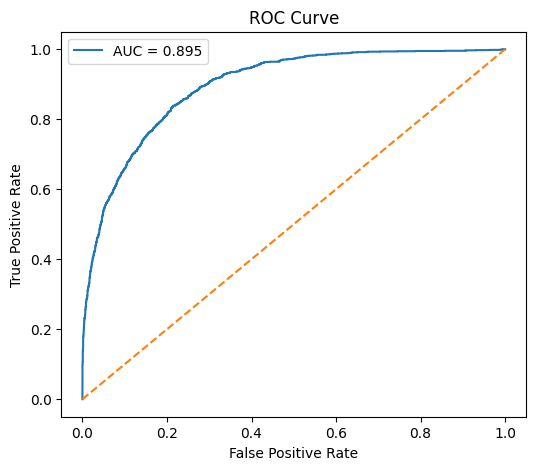

In [42]:
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.savefig("roc_curve.png", dpi=300)

plt.show()

In [43]:
comparison.to_csv("ridge_vs_linear.csv", index=False)
print("Saved Successfully")

Saved Successfully


In [44]:
logistic_comparison.to_csv("logistic_comparison.csv", index=False)
print("Saved Successfully")

Saved Successfully


In [45]:
from google.colab import files

files.download("roc_curve.png")
files.download("ridge_vs_linear.csv")
files.download("logistic_comparison.csv")
files.download("bootstrap_auc_results.csv")
files.download("threshold_analysis.csv")
files.download("classification_report.csv")
files.download("confusion_matrix.csv")
files.download("top3_coefficients.csv")
files.download("model_results.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>